In [ ]:
from pathlib import Path

import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as pp

from helper_scripts import viirs_bayes_maps as vbm
# Project plotting standards
from helper_scripts.plot_style import set_plot_style, savefig
set_plot_style()

In [2]:
PROJ_PATH = Path(".").resolve()
DATA_PATH = PROJ_PATH / "data" 
L2_PATH = DATA_PATH / "L2_files"

In [ ]:
auth = earthaccess.login()

In [24]:
earthaccess.__version__

'0.15.1'

In [22]:
collections = earthaccess.search_datasets(
    keyword="Suomi-NPP VIIRS Level-2 Ocean Color",
)

print(f"Found {len(collections)} collections")
for c in collections[:15]:
    # these attributes exist on earthaccess DataCollection objects
    summ = c.summary()
    print(summ['short-name'], " | ", c.version(), " | ", c.provider())

Found 8 collections


AttributeError: 'DataCollection' object has no attribute 'provider'

In [26]:
bbox = (-40, -48, -20, -38)
date_range = ("2026-01-22", "2026-01-22")
short_name = "VIIRSN_L2_OC_NRT"

# Search for SNPP-VIIRS L2 granules
# Note: VNP09 (or similar) is the short_name for VIIRS L2 Ocean Color
results = earthaccess.search_data(
    short_name=short_name, 
    cloud_hosted=True,
    bounding_box=bbox, # (lower_left_lon, lat, upper_right_lon, lat)
    temporal=date_range,
    granule_name="SNPP_VIIRS*L2.OC*.nc"
)
results

[Collection: {'Version': '2022.0', 'ShortName': 'VIIRSN_L2_OC_NRT'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -38.28894, 'Longitude': -1.09353}, {'Latitude': -43.90075, 'Longitude': -37.94686}, {'Latitude': -64.54601, 'Longitude': -40.07588}, {'Latitude': -55.92623, 'Longitude': 16.80302}, {'Latitude': -38.28894, 'Longitude': -1.09353}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2026-01-22T15:12:00Z', 'EndingDateTime': '2026-01-22T15:17:59Z'}}
 Size(MB): 54.45765781402588
 Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/SNPP_VIIRS.20260122T151200.L2.OC.NRT.nc'],
 Collection: {'ShortName': 'VIIRSN_L2_OC_NRT', 'Version': '2022.0'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -18.79095, 'Longitude': -10.36986}, {'Latitude': -23.26653, 'Longitude': -39.75476}, {'Latitude': -44.02385, 'Longitude': -37.961

In [27]:

# Download to a local folder
files = earthaccess.download(results, local_path=L2_PATH)

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

In [4]:
files = list(L2_PATH.glob("*NRT*"))
print(len(files))

4


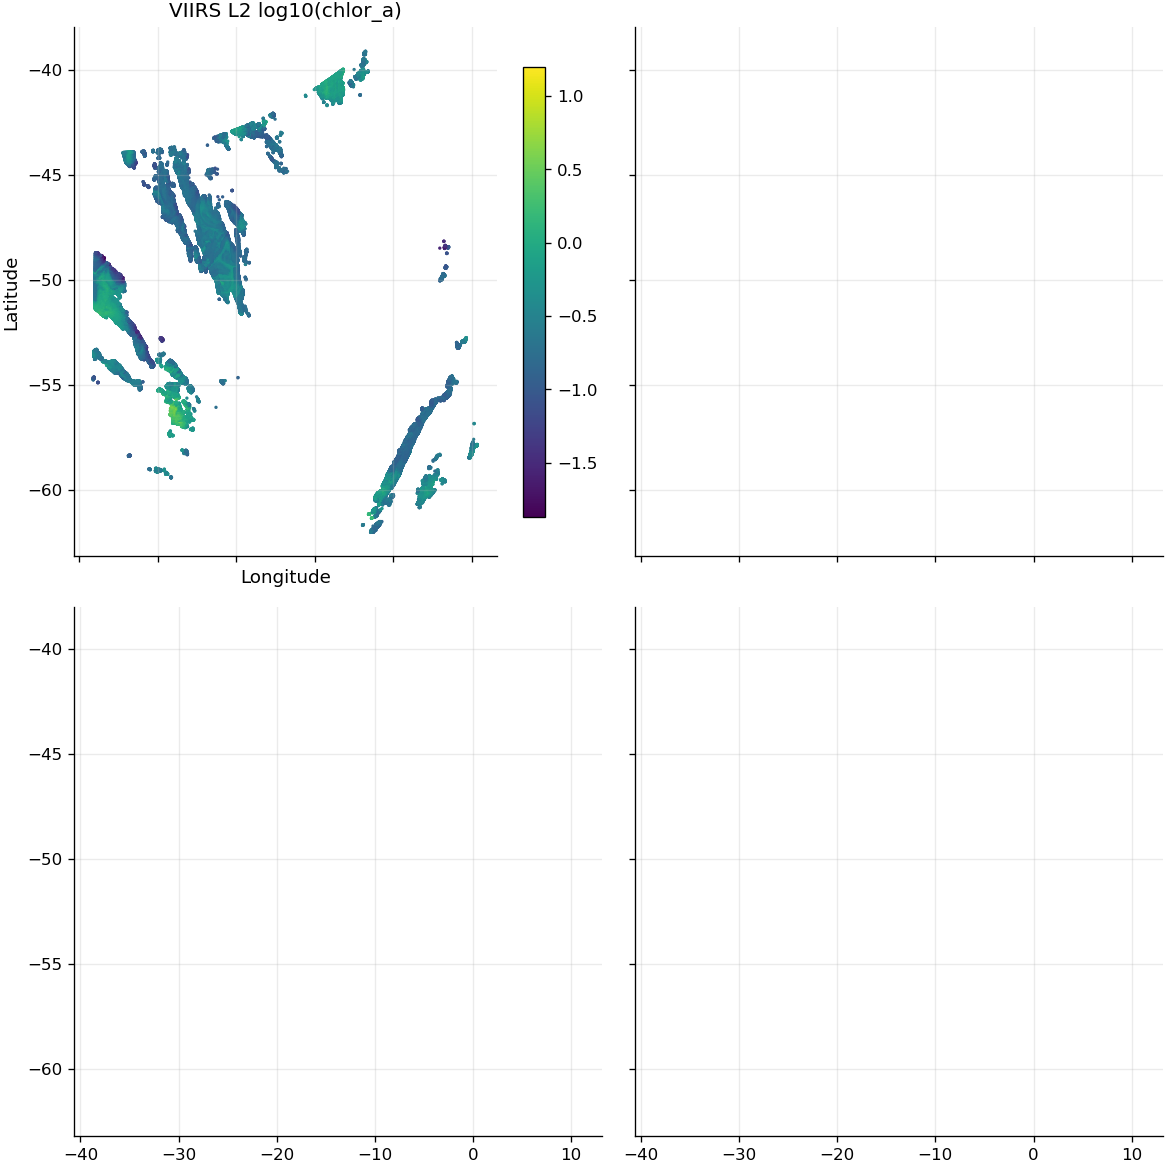

/Users/erdemkarakoylu/projex/bayesian_chl/helper_scripts/viirs_bayes_maps.py:414: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1200 with 6 Axes> than <Figure size 768x576 with 0 Axes> which fig.colorbar is called on.
  pp.colorbar(sc, ax=ax, shrink=0.85)


<Figure size 768x576 with 0 Axes>

/Users/erdemkarakoylu/projex/bayesian_chl/helper_scripts/viirs_bayes_maps.py:414: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1200 with 7 Axes> than <Figure size 768x576 with 0 Axes> which fig.colorbar is called on.
  pp.colorbar(sc, ax=ax, shrink=0.85)


<Figure size 768x576 with 0 Axes>

/Users/erdemkarakoylu/projex/bayesian_chl/helper_scripts/viirs_bayes_maps.py:414: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1200 with 8 Axes> than <Figure size 768x576 with 0 Axes> which fig.colorbar is called on.
  pp.colorbar(sc, ax=ax, shrink=0.85)


<Figure size 768x576 with 0 Axes>

In [ ]:
f, axs = pp.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
for ax, l2_fp in zip(axs.flatten(), files):
    geo = xr.open_dataset(l2_fp, group="geophysical_data")
    nav = xr.open_dataset(l2_fp, group="navigation_data")
    lat = nav["latitude"].values if "latitude" in nav else nav["lat"].values
    lon = nav["longitude"].values if "longitude" in nav else nav["lon"].values
    # If present
    try:
        chl = geo["chlor_a"].values

    except:
        print(f"Could not load chlor_a from {l2_fp}")
        break

    log_chl = np.where(chl > 0, np.log10(chl), np.nan)
    vbm.swath_scatter(lon, lat, log_chl, "VIIRS L2 log10(chlor_a)", s=1, ax=ax)


In [19]:
def swath_scatter_multi(lon, lat, z, title, s=1, norm=None, ax=None, cmap='viridis'):
    """
    Enhanced swath scatter for multi-pane plots with shared scales.
    Returns the PathCollection (mappable) to create a shared colorbar.
    """
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    z   = np.asarray(z)

    m = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(z)
    
    if ax is None:
        fig, ax = pp.subplots(figsize=(9, 6))
    
    # Use the provided norm or default to the local data range
    sc = ax.scatter(
        lon[m].ravel(), 
        lat[m].ravel(), 
        c=z[m].ravel(), 
        s=s, 
        norm=norm, 
        cmap=cmap,
        linewidths=0,
        rasterized=True # Keeps file size small for large L2 swaths
    )
    
    ax.set_title(title)
    return sc

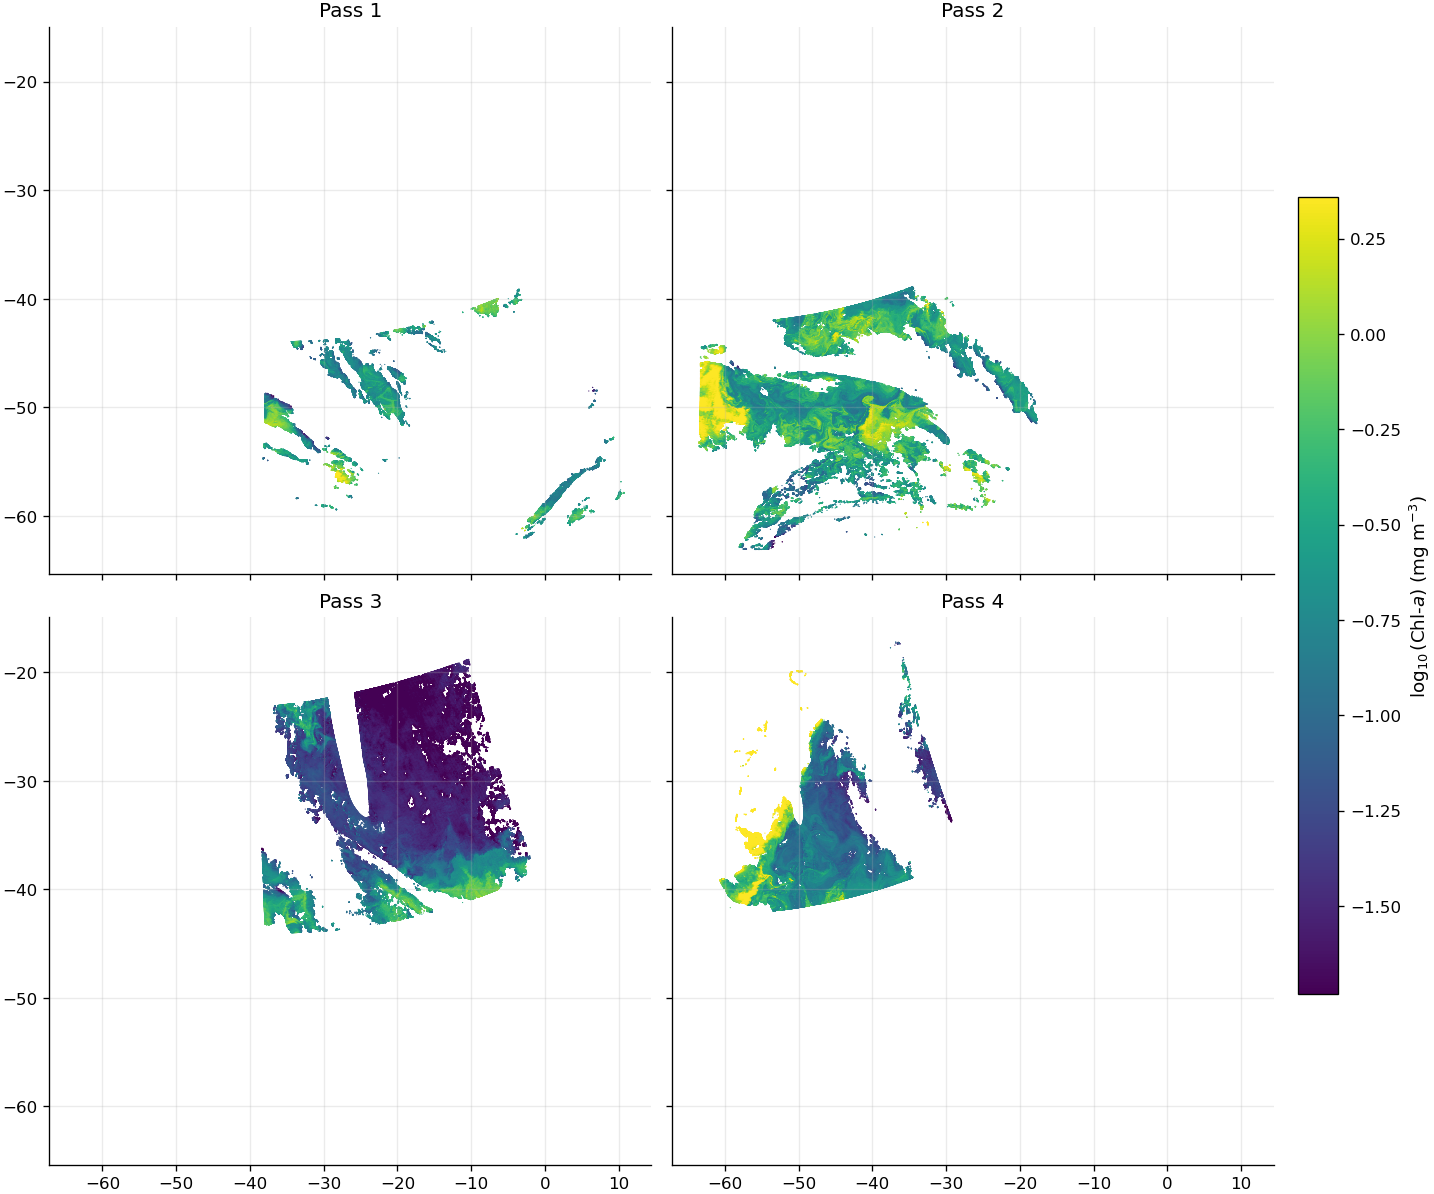

In [20]:
import matplotlib.colors as mcolors

# 1. Pre-calculate the global range for a consistent scale
all_values = []
valid_files = []

for l2_fp in files:
    with xr.open_dataset(l2_fp, group="geophysical_data") as ds:
        if "chlor_a" in ds:
            c = ds["chlor_a"].values
            log_c = np.log10(c[c > 0]) # Filter zeros/negatives
            all_values.append(log_c)
            valid_files.append(l2_fp)

# Flatten and find global bounds (or use manual bounds like -2 to 2)
global_min = np.nanquantile(np.concatenate(all_values), 0.02)
global_max = np.nanquantile(np.concatenate(all_values), 0.98)
shared_norm = mcolors.Normalize(vmin=global_min, vmax=global_max)

# 2. Plotting loop
fig, axs = pp.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True, constrained_layout=True)
axs_flat = axs.flatten()

mappable = None
for i, l2_fp in enumerate(valid_files):
    v = vbm.load_viirs_l2_oc(l2_fp) # Using your existing loader
    geo = xr.open_dataset(l2_fp, group="geophysical_data")
    chl = geo["chlor_a"].values
    log_chl = np.where(chl > 0, np.log10(chl), np.nan)
    
    # Capture the mappable from the scatter call
    mappable = swath_scatter_multi(
        v.lon, v.lat, log_chl, 
        title=f"Pass {i+1}", 
        s=0.5, 
        ax=axs_flat[i], 
        norm=shared_norm
    )

# 3. Add a single colorbar using the last mappable
cbar = fig.colorbar(mappable, ax=axs, orientation='vertical', shrink=0.7, pad=0.02)
cbar.set_label(r"$\log_{10}(\text{Chl-}a)$ (mg m$^{-3}$)")

pp.show()

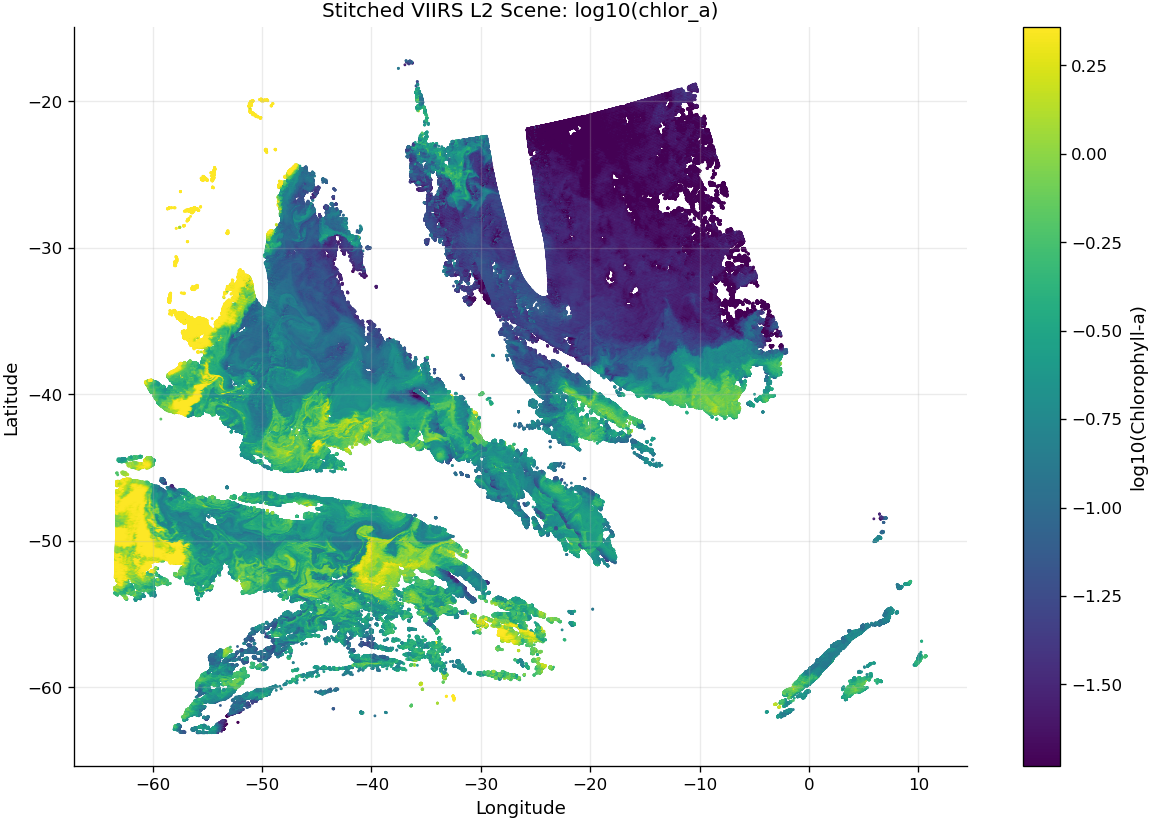

In [22]:
# 1. Initialize collectors
all_lons = []
all_lats = []
all_chls = []

for l2_fp in files:
    try:
        # Using xr.open_dataset context manager to ensure files close
        with xr.open_dataset(l2_fp, group="geophysical_data") as geo, \
             xr.open_dataset(l2_fp, group="navigation_data") as nav:
            
            # Extract coordinates
            lat = nav["latitude"].values if "latitude" in nav else nav["lat"].values
            lon = nav["longitude"].values if "longitude" in nav else nav["lon"].values
            chl = geo["chlor_a"].values
            
            # Filter for valid data only to keep the arrays lean
            mask = np.isfinite(lat) & np.isfinite(lon) & (chl > 0)
            
            all_lons.append(lon[mask])
            all_lats.append(lat[mask])
            all_chls.append(chl[mask])
    except Exception as e:
        print(f"Skipping {l2_fp}: {e}")

# 2. Stitch the data
stitched_lon = np.concatenate(all_lons)
stitched_lat = np.concatenate(all_lats)
stitched_log_chl = np.log10(np.concatenate(all_chls))

# 3. Plot as a single scene
fig, ax = pp.subplots(1, 1, figsize=(12, 8))

# Use a robust scale (2nd to 98th percentile) to prevent outliers from washing out the map
vmin, vmax = np.nanquantile(stitched_log_chl, [0.02, 0.98])

# We use the scatter helper but pass the stitched arrays
# Adding rasterized=True is important here because the stitched array is very large
sc = ax.scatter(
    stitched_lon, 
    stitched_lat, 
    c=stitched_log_chl, 
    s=0.5, 
    vmin=vmin, 
    vmax=vmax, 
    cmap='viridis',
    rasterized=True 
)

ax.set_title("Stitched VIIRS L2 Scene: log10(chlor_a)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
pp.colorbar(sc, label="log10(Chlorophyll-a)")

pp.show()